In [1]:
import os, numpy as np, os
import matplotlib.pyplot as plt
import tools21cm as t2c
import cupy as cp
import itertools
import time

import astropy.units as u
import astropy.constants as cst

from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time
from tqdm import tqdm
from matplotlib.colors import LogNorm
from scipy import stats

In [2]:
def visibility_matrix_func_new_method_cupy(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    # Convert inputs to CuPy arrays
    xyz_coord = cp.array(xyz_coord)
    sky_coord = cp.array(sky_coord)
    I_sky = cp.array(I_sky)
    beam_pattern = cp.array(beam_pattern)

    l_coord, m_coord = cp.meshgrid(sky_coord, sky_coord)
    N_ant = len(xyz_coord)
    N_B = N_ant * (N_ant - 1) // 2
    freq = t2c.cosmo.z_to_nu(redshift) * 1e6
    lam = cst.c.value / freq
    pair_comb = list(itertools.combinations(range(N_ant), 2))
    baseline_coord = cp.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix = cp.zeros((N_ant, N_ant), dtype=cp.complex128)
    visibility_list = cp.empty(N_B, dtype=cp.complex128)

    for i in tqdm(range(N_B)):
        aa, bb = pair_comb[i]
        uv = (xyz_coord[bb] - xyz_coord[aa]) / lam
        baseline_coord[i] = uv
        fringe = cp.exp(-2j * cp.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis = cp.sum(fringe * I_sky * beam_pattern)
        visibility_list[i] = vis
        visibility_matrix[aa, bb] = vis
        visibility_matrix[bb, aa] = cp.conj(vis)
    
    # Transfer results back to CPU if needed
    visibility_list = cp.asnumpy(visibility_list)
    visibility_matrix = cp.asnumpy(visibility_matrix)
    baseline_coord = cp.asnumpy(baseline_coord)
    
    return visibility_list, visibility_matrix, baseline_coord



def filter_baselines_cupy(baselines, visibilities, u_freq, v_freq):
    """Filters baselines and corresponding visibilities based on the range of
    frequencies. This is so that the baselines outside the frequency range of
    the fft image are removed.

    Parameters:
    baselines (ndarray): Numpy array of baseline coordinates.
    visibilities (ndarray): Numpy array of corresponding visibilities.
    u_freq (ndarray): Numpy array of u frequencies.
    v_freq (ndarray): Numpy array of v frequencies.

    Returns:
    filtered_baselines (ndarray): CuPy array of filtered baseline coordinates.
    filtered_visibilities (ndarray): CuPy array of filtered visibilities.
    """
    # Convert inputs to CuPy arrays
    baselines_cp = cp.array(baselines)
    visibilities_cp = cp.array(visibilities)
    u_freq_cp = cp.array(u_freq)
    v_freq_cp = cp.array(v_freq)
    
    # Find the min and max frequencies
    u_min, u_max = cp.min(u_freq_cp), cp.max(u_freq_cp)
    v_min, v_max = cp.min(v_freq_cp), cp.max(v_freq_cp)
    
    # Filter baselines based on frequency range
    x = baselines_cp[:, 0]
    y = baselines_cp[:, 1]
    mask = (u_min <= x) & (x <= u_max) & (v_min <= y) & (y <= v_max)
    
    # Apply mask to baselines and visibilities
    filtered_baselines = baselines_cp[mask]
    filtered_visibilities = visibilities_cp[mask]
    
    return filtered_baselines, filtered_visibilities



def _splice_values_equal_bins_cupy(blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    """
    The provided arrays should be cupy arrays.
    """
    # Step 1: Calculate the number of elements per bin
    num_elements = len(blmag_sorted)
    elements_per_bin = num_elements // num_bins
    extra_elements = num_elements % num_bins

    # Step 2: Create an array of bin sizes
    bin_sizes = cp.full(num_bins, elements_per_bin)
    bin_sizes[:extra_elements] += 1

    # Step 3: Calculate the cumulative sum of bin sizes
    cumulative_sizes = cp.cumsum(bin_sizes)
    cumulative_sizes_np = cp.asnumpy(cumulative_sizes)  # Convert to NumPy array

    # Step 4: Initialize the bins
    blcoord_bins = cp.split(blcoord_sorted, cumulative_sizes_np[:-1])
    blmag_bins = cp.split(blmag_sorted, cumulative_sizes_np[:-1])
    vis_bins = cp.split(vis_sorted, cumulative_sizes_np[:-1])

    return blcoord_bins, blmag_bins, vis_bins



def _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins):
    bins = cp.linspace(np.min(blmag_sorted_transformed), np.max(blmag_sorted_transformed), num_bins)
    bin_indices = np.digitize(blmag_sorted_transformed, bins) - 1
    
    # Use histogram to count the occurrences of each bin
    hist, _ = cp.histogram(bin_indices, bins=cp.arange(0, num_bins + 1))

    # Calculate the cumulative counts to determine the indices where each bin's values start and end
    cum_counts = cp.cumsum(hist)
    cumulative_sizes_np = cp.asnumpy(cum_counts)  # Convert to NumPy array

    bin_blcoords = cp.split(blcoord_sorted, cumulative_sizes_np[:-1])
    bin_vis = cp.split(vis_sorted, cumulative_sizes_np[:-1])
    bin_blmags = cp.split(blmag_sorted, cumulative_sizes_np[:-1])

    return bin_blcoords, bin_vis, bin_blmags



def compute_vals_cupy(blcoord, vis, sigma_0, V_0, bin_number):

    bin_len = len(blcoord)
    if bin_len == 0 or bin_len == 1:
        return 0, 0, 0

    # Create a meshgrid for vectorized pairwise operations
    idx_i, idx_j = np.triu_indices(bin_len, k=1)
    idx_i = cp.asarray(idx_i)
    idx_j = cp.asarray(idx_j)

    # Calculate pairwise distances
    delta= blcoord[idx_i] - blcoord[idx_j]
    distance_norm = cp.linalg.norm(delta, axis=1)
    
    combination_len_unfiltered= len(distance_norm)
    
    # Filter pairs where distance is less than or equal to sigma_0
    valid_pairs = distance_norm > sigma_0
    if not cp.any(valid_pairs):
        return 0, 0, 0

    distance_norm = distance_norm[valid_pairs]
    idx_i = idx_i[valid_pairs]
    idx_j = idx_j[valid_pairs]
    
    combination_len_filtered= len(distance_norm)
    print("Bin", bin_number, ":Theoretical combinations: ", combination_len_unfiltered,
         " - When filtered: ", combination_len_filtered)
    
    # Calculate weights
    weight = cp.exp(-(distance_norm**2) / sigma_0**2)

    # Calculate the visibility product
    visibility_product = vis[idx_i] * cp.conj(vis[idx_j])

    #Calclating the bare estimator
    be_numerator = cp.sum(weight * visibility_product)
    be_denominator = cp.sum(weight * V_0 * cp.exp(-(distance_norm**2) / (sigma_0**2)))

    #Calculating the mean of ell
    l_i = 2 * cp.pi * cp.sqrt(blcoord[idx_i, 0]**2 + blcoord[idx_i, 1]**2)
    exp_weight_distance = weight * cp.exp(-(distance_norm**2) / (sigma_0**2))

    ell_numerator = cp.sum(exp_weight_distance * l_i)
    ell_denominator = cp.sum(exp_weight_distance)

    #Computing arrays needed for the error (variance)
    #Eb_square_mean_numerator = cp.sum((exp_weight_distance * 5.13 * 1e-4 * (1000 / l_i) ** 2.34) ** 2)
    #Eb_mean_square_numerator = cp.sum(exp_weight_distance * 5.13 * 1e-4 * (1000 / l_i) ** 2.34)
    Eb_square_mean_numerator = cp.sum((exp_weight_distance * 513 * (1000 / l_i) ** 2.34) ** 2)
    Eb_mean_square_numerator = cp.sum(exp_weight_distance * 513 * (1000 / l_i) ** 2.34)
    Eb_denominator = cp.sum(exp_weight_distance)

    bare_estimator = cp.abs(be_numerator) / be_denominator
    ell_mean = ell_numerator / ell_denominator
    var_squared = (Eb_square_mean_numerator / Eb_denominator - (Eb_mean_square_numerator / Eb_denominator) ** 2)

    # Convert results back to numpy arrays
    bare_estimator = cp.asnumpy(bare_estimator)
    ell_mean = cp.asnumpy(ell_mean)
    var_squared = cp.asnumpy(var_squared)

    return bare_estimator, ell_mean, np.abs(var_squared)



def bare_estimator_func_cupy(baselines, visibilities, theta_fwhm, num_bins, bin_type, precision = 'single'):
    # Set data types based on the precision parameter
    if precision == 'single':
        float_dtype = cp.float32
        complex_dtype = cp.complex64
    elif precision == 'double':
        float_dtype = cp.float64
        complex_dtype = cp.complex128
    else:
        raise ValueError("Unsupported precision type. Use 'single' or 'double'.")    
    
    theta_0 = 0.6 * theta_fwhm
    V_0 = np.pi * theta_0**2 / 2
    sigma_0 = 0.76 / theta_fwhm

    start_time = time.time()
    # Step 0: turn arrays into cupy arrays
    baselines= cp.asarray(baselines, dtype= float_dtype)
    visibilities= cp.asarray(visibilities, dtype= complex_dtype)

    # Step 1: Calculate the baseline magnitudes
    bl_mag = cp.linalg.norm(baselines, axis=1)

    # Stack baselines, magnitudes, and visibilities into a single array for sorting
    #combined_array = cp.hstack((baselines[:,0, None], baselines[:,1, None], bl_mag[:, None], visibilities[:, None]))
    combined_array = cp.hstack((baselines[:], bl_mag[:, None], visibilities[:, None]))

    # Sort the combined array based on the magnitudes
    sorted_combined_array = combined_array[cp.argsort(combined_array[:,2])]

    # Split the sorted array back into individual components
    blcoord_sorted = sorted_combined_array[:, 0:2]
    blmag_sorted = sorted_combined_array[:, 2]
    vis_sorted = sorted_combined_array[:, -1]
    
    print("Length of input arrays: ", len(blmag_sorted))

    if bin_type == "log":
        blmag_sorted_transformed = cp.log10(blmag_sorted)
        blcoord_bins, blmag_bins, vis_bins = _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "linear":
        blmag_sorted_transformed = blmag_sorted
        blcoord_bins, blmag_bins, vis_bins = _splice_values_function_fit_cupy(blmag_sorted_transformed, blcoord_sorted, blmag_sorted, vis_sorted, num_bins)

    elif bin_type == "equal_length":
        blcoord_bins, blmag_bins, vis_bins = _splice_values_equal_bins_cupy(blcoord_sorted, blmag_sorted, vis_sorted, num_bins)
    else:
        raise ValueError("Unsupported bin_type")

    end_time = time.time()
    print('Time to sort and bin values: ', end_time-start_time, 's')

    # Verify the bins
    for i, bin in enumerate(blcoord_bins):
        print(f"Bin {i+1}: {len(bin)} elements - Combinations: {int(len(bin)*(len(bin)-1) / 2)}")
    # Print to verify the results
    print("Total elements after binning: ", cp.sum(cp.array([len(bin) for bin in blmag_bins])))

    bare_estimators = np.empty(num_bins, dtype=float_dtype)
    average_ells = np.empty(num_bins, dtype=float_dtype)
    square_variances = np.empty(num_bins, dtype=float_dtype)

    start_time = time.time()
    for i in range(num_bins):
        bin_number = i + 1
        BE, ell_avg, var_squared= compute_vals_cupy(blcoord_bins[i], vis_bins[i], sigma_0, V_0, bin_number) 

        bare_estimators[i] = BE
        average_ells[i] = ell_avg
        square_variances[i] = var_squared
    end_time = time.time()
    print('Time to run the bare estimator: ', end_time-start_time, 's')
    
    return bare_estimators, average_ells, square_variances



def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    @ Ghara et al. (2017)

    Parameters
    ----------
    z           : float
        Redshift observed with 21-cm.
    ncells      : int
        Number of cells on each axis.
    boxsize     : float
        Size of the FOV in Mpc.
    rseed: int
        random seed to have the same realisation (Default: False).
    Returns
    -------
    A 2D numpy array of brightness temperature in mK.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)
    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): np.random.seed(rseed)
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1

    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        #C_syn = A150*(1000/l_cb)**beta_*(nu/nu_s)**(-2*a_syn-2*Da_syn*np.log(nu/nu_s))
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j) * np.sqrt(2)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i] = t2c.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    return gf_data.squeeze()

In [3]:
# frequency resolution of SKA-Low
dfreq = 100*u.kHz
# observed frequency and redshift by SKA-Low
freqs = 106. *u.MHz + np.arange(0, 901) * dfreq
redshifts = t2c.nu_to_z(freqs.to('MHz').value)
lams = (cst.c.value / freqs.to('Hz').value) * u.m
#--------------------------------------------------
L_box = 2048 * u.Mpc
N_pix = 1024
random_seed = 918

# define redshift and corresponding observed frequency
i_channel = 600
z = redshifts[i_channel]
freq = freqs[i_channel]
lam = lams[i_channel]
theta_fwhm = (1.03 * lam.value / 40) * u.rad
# galactic foreground syncrotron emeission model
dT = galactic_synch_fg_custom(z=z, ncells=N_pix, boxsize=L_box.value, rseed=random_seed) * u.mK

#--------------------------------------------------
# angular resolution in rad
dthet = L_box / ((1+z)*cosmo.angular_diameter_distance(z)*N_pix) * u.rad
# field of view
FoV = (dthet*N_pix).to('deg')
pixel_area = (dthet*dthet).to('sr')

#--------------------------------------------------
# equivalence to convert temperature (mK) to brightness (Jy)
equiv_jy2k = u.brightness_temperature(frequency=freq, beam_area=pixel_area)
# sky model in Jy units
dT_jy = dT.to('Jy', equivalencies=equiv_jy2k)

#--------------------------------------------------
# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, N_pix).to('rad').value
# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)
# Load the SKA-low layout
skalow_layout = np.load('../SKA_material/SKA_ant_coords.npy')
# Generating a telescope beam pattern
theta_0 = 0.6* theta_fwhm
beam_pattern = np.exp(-((l_coord**2 + m_coord**2) / theta_0.value**2))
visls_skalow, vismx_skalow, bls_skalow = visibility_matrix_func_new_method_cupy(skalow_layout, thet, z, dT_jy.value, beam_pattern)
# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(dT_jy.shape[0], dthet.value)
vv= np.fft.fftfreq(dT_jy.shape[1], dthet.value)
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

#--------------------------------------------------
filter_blsskalow, filter_visskalow = filter_baselines_cupy(bls_skalow, visls_skalow, u_freq, v_freq)
filter_blsskalow = cp.asnumpy(filter_blsskalow)
filter_visskalow = cp.asnumpy(filter_visskalow)

#--------------------------------------------------
num_bins = 30
binning_method = 'equal_length'
precision = 'single'
bare_estimator_skalow, ell_mean_skalow, var_squared_skalow= bare_estimator_func_cupy(filter_blsskalow, filter_visskalow, theta_fwhm.value, num_bins, binning_method, 'double')

100%|██████████| 130816/130816 [02:59<00:00, 730.33it/s]


Length of input arrays:  72651
Time to sort and bin values:  0.4369931221008301 s
Bin 1: 2422 elements - Combinations: 2931831
Bin 2: 2422 elements - Combinations: 2931831
Bin 3: 2422 elements - Combinations: 2931831
Bin 4: 2422 elements - Combinations: 2931831
Bin 5: 2422 elements - Combinations: 2931831
Bin 6: 2422 elements - Combinations: 2931831
Bin 7: 2422 elements - Combinations: 2931831
Bin 8: 2422 elements - Combinations: 2931831
Bin 9: 2422 elements - Combinations: 2931831
Bin 10: 2422 elements - Combinations: 2931831
Bin 11: 2422 elements - Combinations: 2931831
Bin 12: 2422 elements - Combinations: 2931831
Bin 13: 2422 elements - Combinations: 2931831
Bin 14: 2422 elements - Combinations: 2931831
Bin 15: 2422 elements - Combinations: 2931831
Bin 16: 2422 elements - Combinations: 2931831
Bin 17: 2422 elements - Combinations: 2931831
Bin 18: 2422 elements - Combinations: 2931831
Bin 19: 2422 elements - Combinations: 2931831
Bin 20: 2422 elements - Combinations: 2931831
Bin 21:

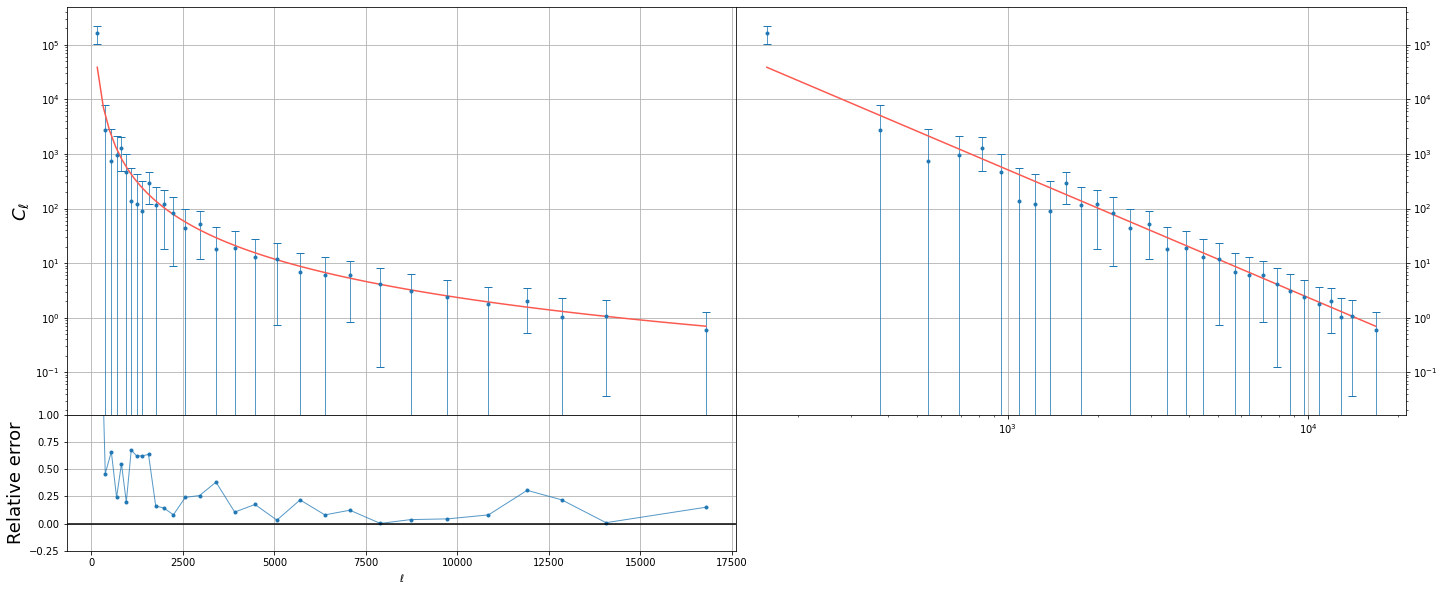

In [4]:
# Create a larger figure with more space
f = plt.figure(figsize=(24, 10))  # Adjust the width and height as needed
gs = f.add_gridspec(2, 2, hspace=0., wspace=0., height_ratios=[3, 1])  # Add a second column
ax1 = f.add_subplot(gs[0, 0])
ax2 = f.add_subplot(gs[1, 0])  # Original plots in the first column
ax3 = f.add_subplot(gs[0, 1])  # New plot in the second column

# Plot the data in the first column
ax1.errorbar(ell_mean_skalow, bare_estimator_skalow, np.sqrt(var_squared_skalow), 
              color="#1f77b4",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
ells_skalow = np.linspace(np.min(ell_mean_skalow), np.max(ell_mean_skalow), 100)
ax1.plot(ells_skalow, 513 * (1000 / ells_skalow) ** 2.34, color='#FC5A50')
ax1.set_ylabel(r"$C_{\ell}$", fontsize = 18)
ax1.set_yscale('log')
ax1.set_xticklabels([])
ax1.grid()


# Calculate true values and plot relative error in the first column
cylpowerspec_truevals = 513 * (1000 / ell_mean_skalow) ** 2.34
ax2.plot(ell_mean_skalow, np.abs((bare_estimator_skalow - cylpowerspec_truevals) / cylpowerspec_truevals), ".", color='#1f77b4')
ax2.plot(ell_mean_skalow, np.abs((bare_estimator_skalow - cylpowerspec_truevals) / cylpowerspec_truevals), alpha=0.75, color='#1f77b4', linewidth=1)
ax2.axhline(y=0, xmin=0.0, xmax=1.0, color="k")
ax2.set_ylabel('Relative error', fontsize = 18)
ax2.set_ylim(-0.25, 1)
ax2.set_xlabel('$\ell$')
ax2.grid()

# Plot the data in the second column, upper row
ax3.errorbar(ell_mean_skalow, bare_estimator_skalow, np.sqrt(var_squared_skalow), 
              color="#1f77b4",
              elinewidth=0.75,
              capsize=4,
              fmt="o",
              markersize=3)
ax3.plot(ells_skalow, 513 * (1000 / ells_skalow) ** 2.34, color='#FC5A50')
ax3.set_yscale('log')
ax3.set_xscale('log')
ax3.grid()
# Move y-ticks to the right edge of the upper right plot
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")

# Show the figure
plt.show()